In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [56]:
circuits = pd.read_csv("../data/cleaned/circuits.csv")
constructors = pd.read_csv("../data/cleaned/constructors.csv")
constructor_results = pd.read_csv("../data/cleaned/constructor_results.csv")
constructor_standings = pd.read_csv("../data/cleaned/constructor_standings.csv")
drivers = pd.read_csv("../data/cleaned/drivers.csv")
driver_standings = pd.read_csv("../data/cleaned/driver_standings.csv")
lap_times = pd.read_csv("../data/cleaned/lap_times.csv")
pit_stops = pd.read_csv("../data/cleaned/pit_stops.csv")
qualifying = pd.read_csv("../data/cleaned/qualifying.csv")
races = pd.read_csv("../data/cleaned/races.csv")
results = pd.read_csv("../data/cleaned/results.csv")
seasons = pd.read_csv("../data/cleaned/seasons.csv")
sprint_results = pd.read_csv("../data/cleaned/sprint_results.csv")
status = pd.read_csv("../data/cleaned/status.csv")

In [57]:
datasets = {
    "circuits": circuits,
    "constructors": constructors,
    "constructor_results": constructor_results,
    "constructor_standings": constructor_standings,
    "drivers": drivers,
    "driver_standings": driver_standings,
    "lap_times": lap_times,
    "pit_stops": pit_stops,
    "qualifying": qualifying,
    "races": races,
    "results": results,
    "seasons": seasons,
    "sprint_results": sprint_results,
    "status": status
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

circuits: (78, 9)
constructors: (214, 5)
constructor_results: (12986, 5)
constructor_standings: (13752, 7)
drivers: (865, 9)
driver_standings: (35603, 7)
lap_times: (876797, 6)
pit_stops: (22548, 7)
qualifying: (11212, 9)
races: (1171, 18)
results: (27480, 18)
seasons: (77, 2)
sprint_results: (568, 17)
status: (141, 2)


In [58]:
print(f"Total Seasons      : {seasons.shape[0]}")
print(f"Total Races        : {races.shape[0]}")
print(f"Total Drivers      : {drivers.shape[0]}")
print(f"Total Constructors : {constructors.shape[0]}")
print(f"Total Circuits     : {circuits.shape[0]}")

Total Seasons      : 77
Total Races        : 1171
Total Drivers      : 865
Total Constructors : 214
Total Circuits     : 78


### Observations

- The dataset contains 77 Formula 1 seasons.
- A total of 1,171 races have been conducted.
- The dataset includes 865 drivers.
- There are 214 constructors.
- A total of 78 circuits are present.

These KPIs provide a high-level overview of the Formula 1 dataset before performing detailed analysis.

## Race Distribution by Season

In [59]:
races_per_season = races.groupby("year")["raceId"].count()

races_per_season

year
1950     7
1951     8
1952     8
1953     9
1954     9
        ..
2022    22
2023    22
2024    24
2025    24
2026    22
Name: raceId, Length: 77, dtype: int64

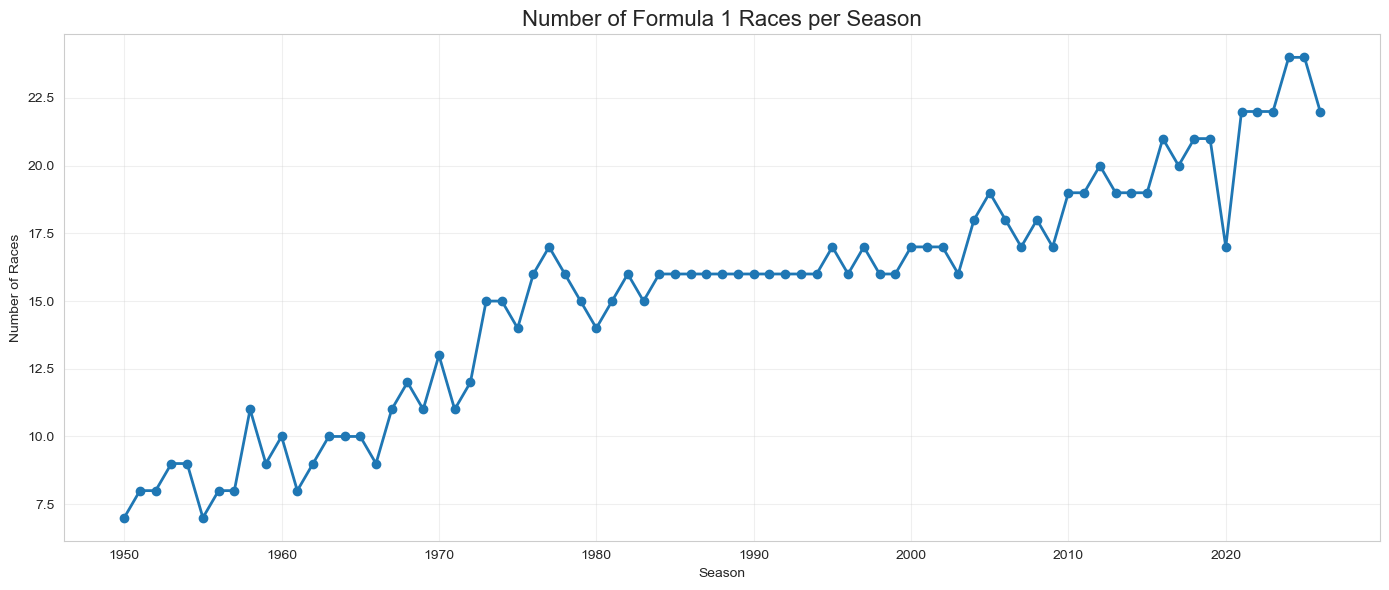

In [60]:
plt.figure(figsize=(14, 6))

plt.plot(
    races_per_season.index,
    races_per_season.values,
    marker="o",
    linewidth=2
)

plt.title("Number of Formula 1 Races per Season", fontsize=16)
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- The number of races has generally increased over the years.
- Early Formula 1 seasons had fewer races.
- Modern seasons contain significantly more races, indicating the expansion of the Formula 1 calendar.
- Any sudden increase or decrease in races can be investigated further.

## Seasons with Maximum and Minimum Number of Races

### Objective

Identify the seasons with the highest and lowest number of Formula 1 races.

In [61]:
print("Season with Maximum Races:")
print(races_per_season.idxmax(), "-", races_per_season.max(), "races")

print("\nSeason with Minimum Races:")
print(races_per_season.idxmin(), "-", races_per_season.min(), "races")

Season with Maximum Races:
2024 - 24 races

Season with Minimum Races:
1950 - 7 races


### Observations

- The 2024 Formula 1 season had the highest number of races, with **24 races**, making it the longest season in the dataset.
- The inaugural 1950 Formula 1 season had the fewest races, with **7 races**.
- This indicates a significant expansion of the Formula 1 calendar over the decades, reflecting the sport's global growth and increasing popularity.

## Average Number of Races per Season

### Objective

Calculate the average number of Formula 1 races conducted in a season.

In [62]:
average_races = races_per_season.mean()

print(f"Average Races per Season: {average_races:.2f}")

Average Races per Season: 15.21


### Observations

- On average, each Formula 1 season consists of **XX.XX races**.
- Modern seasons generally exceed this average, whereas earlier seasons fall below it.

# Circuit Analysis

## Countries Hosting Formula 1 Circuits

### Objective

Identify the countries with the highest number of Formula 1 circuits.

In [63]:
circuits_by_country = (
    circuits.groupby("country")["circuitId"]
    .count()
    .sort_values(ascending=False)
)

circuits_by_country.head(10)

country
USA         11
Spain        7
France       7
Portugal     4
UK           4
Italy        4
Belgium      3
Canada       3
Germany      3
Japan        3
Name: circuitId, dtype: int64

### Observations

- The **USA** has the highest number of Formula 1 circuits, with **11 circuits**.
- **Spain** and **France** are tied for the second-highest number of circuits, with **7 circuits** each.
- **Portugal, the UK, and Italy** each have **4 circuits**.
- Most of the top countries are located in **Europe**, highlighting the historical roots of Formula 1 in Europe.
- Although the USA has the highest number of circuits in the dataset, not all of them have been part of the Formula 1 calendar in every season.

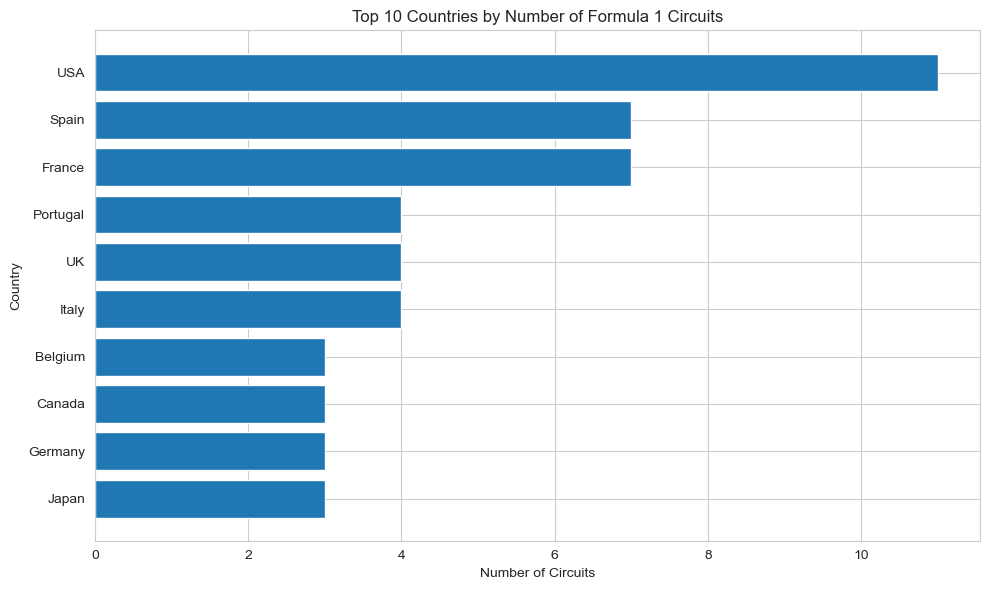

In [64]:
top10 = circuits_by_country.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10.index, top10.values)

plt.title("Top 10 Countries by Number of Formula 1 Circuits")
plt.xlabel("Number of Circuits")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Most Frequently Used Formula 1 Circuits

### Objective

Identify the circuits that have hosted the highest number of Formula 1 races.

In [65]:
race_circuits = races.merge(
    circuits[["circuitId", "name"]],
    on="circuitId",
    how="left",
    suffixes=("_race", "_circuit")
)

In [66]:
top_circuits = (
    race_circuits.groupby("name_circuit")["raceId"]
    .count()
    .sort_values(ascending=False)
)

top_circuits.head(10)

name_circuit
Autodromo Nazionale di Monza    76
Circuit de Monaco               72
Silverstone Circuit             61
Circuit de Spa-Francorchamps    59
Circuit Gilles Villeneuve       45
Autódromo José Carlos Pace      43
Hungaroring                     41
Nürburgring                     41
Red Bull Ring                   40
Hockenheimring                  37
Name: raceId, dtype: int64

### Observations

- **Autodromo Nazionale di Monza** has hosted the highest number of Formula 1 races, with **76 races**.
- **Circuit de Monaco** ranks second with **72 races**, highlighting its historic significance in Formula 1.
- **Silverstone Circuit** has hosted **61 races**, making it one of the most iconic venues in the sport.
- The top 10 circuits are predominantly located in **Europe**, reflecting Formula 1's historical origins.
- These circuits have remained integral to the Formula 1 calendar across multiple decades.

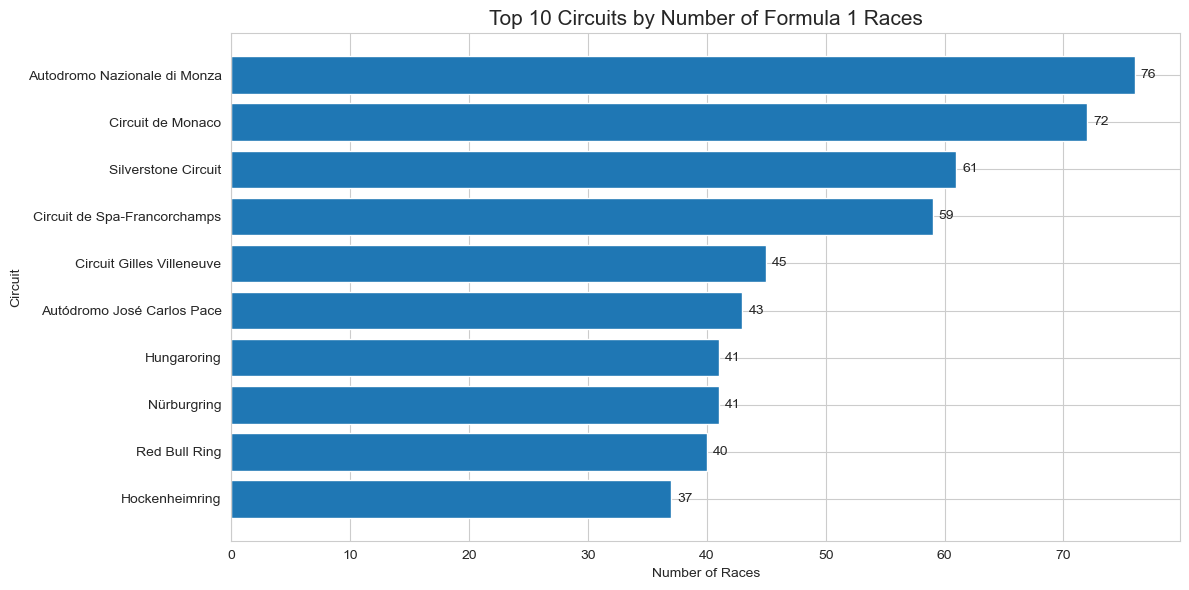

In [67]:
top10 = top_circuits.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10.index, top10.values)

plt.title("Top 10 Circuits by Number of Formula 1 Races", fontsize=15)
plt.xlabel("Number of Races")
plt.ylabel("Circuit")

plt.gca().invert_yaxis()

# Add value labels
for index, value in enumerate(top10.values):
    plt.text(value + 0.5, index, str(value), va="center")

plt.tight_layout()

plt.show()

# Driver Analysis

In this section, we explore the performance and participation of Formula 1 drivers over the years. We analyze which drivers have participated in the most races, achieved the highest number of wins and podium finishes, and maintained the best average finishing positions. These insights help identify the most experienced and successful drivers in Formula 1 history.

## Drivers with Most Race Starts

This analysis identifies the drivers who have participated in the highest number of Formula 1 races. A higher number of race starts reflects a driver's longevity, consistency, and sustained presence in the sport.

In [68]:
driver_starts = (
    results.groupby("driverId")
    .size()
    .reset_index(name="Race Starts")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId")
)

driver_starts["Driver"] = (
    driver_starts["forename"] + " " + driver_starts["surname"]
)

driver_starts = driver_starts.sort_values(
    "Race Starts",
    ascending=False
)

driver_starts.head(10)

,driverId,Race Starts,forename,surname,Driver
3,4,439,Fernando,Alonso,Fernando Alonso
0,1,391,Lewis,Hamilton,Lewis Hamilton
7,8,352,Kimi,Räikkönen,Kimi Räikkönen
21,22,326,Rubens,Barrichello,Rubens Barrichello
17,18,309,Jenson,Button,Jenson Button
29,30,308,Michael,Schumacher,Michael Schumacher
19,20,300,Sebastian,Vettel,Sebastian Vettel
813,815,294,Sergio,Pérez,Sergio Pérez
12,13,271,Felipe,Massa,Felipe Massa
806,807,265,Nico,Hülkenberg,Nico Hülkenberg


## Drivers with Most Wins

Winning races is the ultimate measure of success in Formula 1. This analysis counts the total number of race victories achieved by each driver and ranks them accordingly.

In [69]:
wins = results[results["positionOrder"] == 1]

driver_wins = (
    wins.groupby("driverId")
    .size()
    .reset_index(name="Wins")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId")
)

driver_wins["Driver"] = (
    driver_wins["forename"] + " " + driver_wins["surname"]
)

driver_wins = driver_wins.sort_values(
    "Wins",
    ascending=False
)

driver_wins.head(10)

,driverId,Wins,forename,surname,Driver
0,1,106,Lewis,Hamilton,Lewis Hamilton
15,30,91,Michael,Schumacher,Michael Schumacher
107,830,71,Max,Verstappen,Max Verstappen
11,20,53,Sebastian,Vettel,Sebastian Vettel
29,117,51,Alain,Prost,Alain Prost
27,102,41,Ayrton,Senna,Ayrton Senna
2,4,32,Fernando,Alonso,Fernando Alonso
26,95,31,Nigel,Mansell,Nigel Mansell
64,328,27,Jackie,Stewart,Jackie Stewart
40,182,25,Niki,Lauda,Niki Lauda



## Drivers with Most Podiums

A podium finish represents a top-three result in a race. This analysis highlights the drivers who have consistently finished among the top three positions throughout their careers.

In [70]:
podiums = results[
    results["positionOrder"] <= 3
]

driver_podiums = (
    podiums.groupby("driverId")
    .size()
    .reset_index(name="Podiums")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId")
)

driver_podiums["Driver"] = (
    driver_podiums["forename"] + " " + driver_podiums["surname"]
)

driver_podiums = driver_podiums.sort_values(
    "Podiums",
    ascending=False
)

driver_podiums.head(10)

,driverId,Podiums,forename,surname,Driver
0,1,207,Lewis,Hamilton,Lewis Hamilton
20,30,155,Michael,Schumacher,Michael Schumacher
207,830,131,Max,Verstappen,Max Verstappen
15,20,122,Sebastian,Vettel,Sebastian Vettel
47,117,106,Alain,Prost,Alain Prost
3,4,106,Fernando,Alonso,Fernando Alonso
5,8,103,Kimi,Räikkönen,Kimi Räikkönen
42,102,80,Ayrton,Senna,Ayrton Senna
17,22,68,Rubens,Barrichello,Rubens Barrichello
204,822,67,Valtteri,Bottas,Valtteri Bottas


## Average Finishing Position

This analysis calculates the average finishing position of each driver across all races. Lower average values indicate stronger overall performance and greater consistency during a driver's career.

In [71]:
avg_finish = (
    results.groupby("driverId")["positionOrder"]
    .mean()
    .reset_index(name="Average Finish")
    .merge(drivers[["driverId", "forename", "surname"]], on="driverId")
)

avg_finish["Driver"] = (
    avg_finish["forename"] + " " + avg_finish["surname"]
)

avg_finish = avg_finish.sort_values("Average Finish")

avg_finish.head(10)

,driverId,Average Finish,forename,surname,Driver
590,591,2.000000,George,Amick,George Amick
801,802,2.000000,Dorino,Serafini,Dorino Serafini
765,766,3.500000,Lee,Wallard,Lee Wallard
785,786,4.375000,Luigi,Fagioli,Luigi Fagioli
578,579,4.793103,Juan,Fangio,Juan Fangio
694,695,5.000000,Oscar,Gálvez,Oscar Gálvez
742,743,5.000000,Eric,Thompson,Eric Thompson
793,794,5.000000,Joie,Chitwood,Joie Chitwood
0,1,5.196931,Lewis,Hamilton,Lewis Hamilton
828,830,5.569672,Max,Verstappen,Max Verstappen


### Summary

The driver analysis provides valuable insights into participation, consistency, and success in Formula 1. Metrics such as race starts, wins, podium finishes, and average finishing positions help distinguish experienced drivers from the most successful competitors in the sport.

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

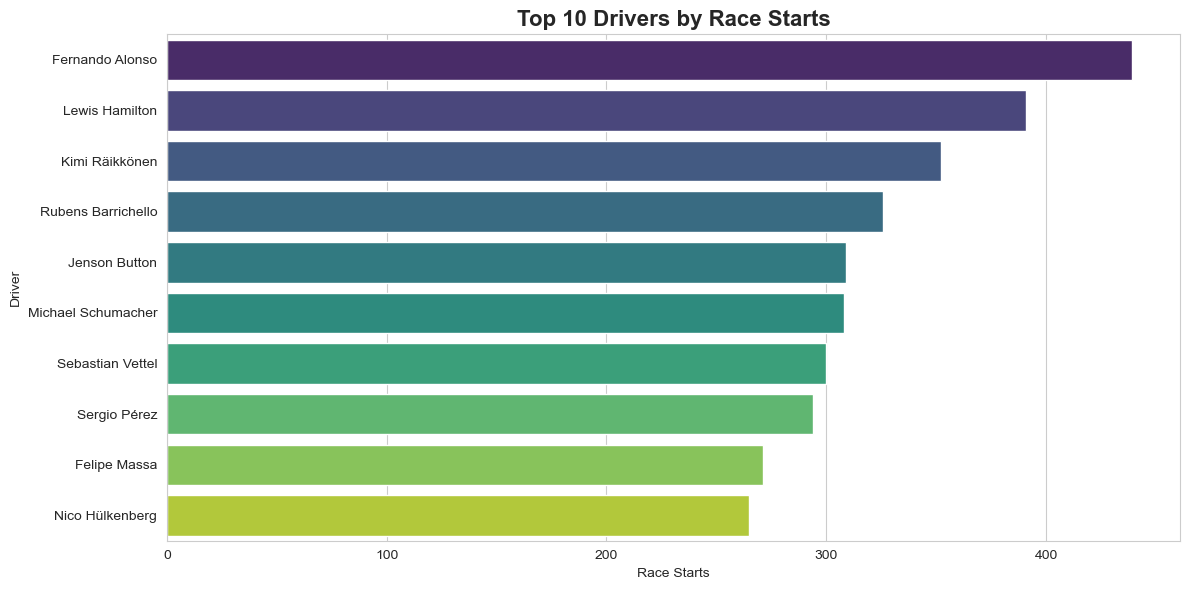

In [73]:
top10_starts = driver_starts.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_starts,
    x="Race Starts",
    y="Driver",
    hue="Driver",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Drivers by Race Starts", fontsize=16, fontweight="bold")
plt.xlabel("Race Starts")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

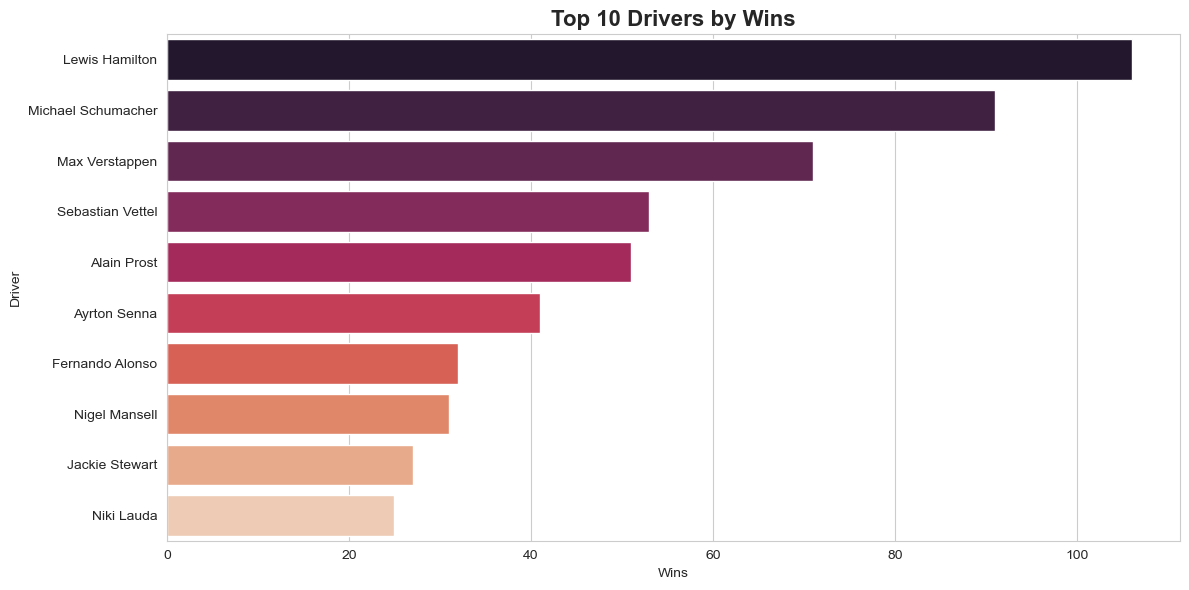

In [74]:
top10_wins = driver_wins.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_wins,
    x="Wins",
    y="Driver",
    hue="Driver",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Drivers by Wins", fontsize=16, fontweight="bold")
plt.xlabel("Wins")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

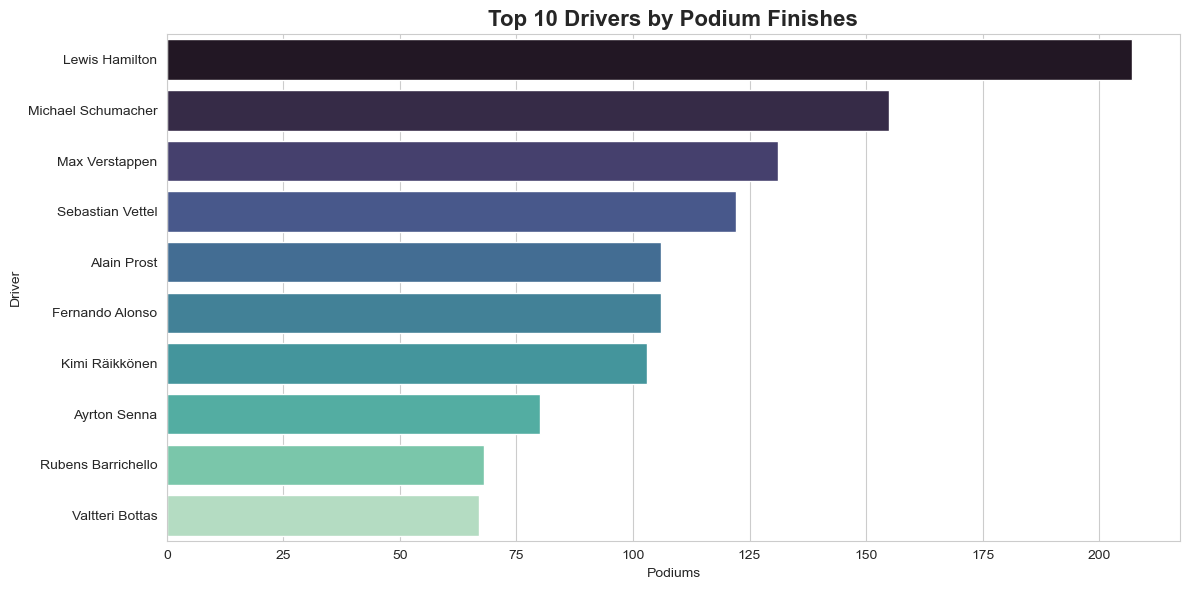

In [75]:
top10_podiums = driver_podiums.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_podiums,
    x="Podiums",
    y="Driver",
    hue="Driver",
    palette="mako",
    legend=False
)

plt.title("Top 10 Drivers by Podium Finishes", fontsize=16, fontweight="bold")
plt.xlabel("Podiums")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

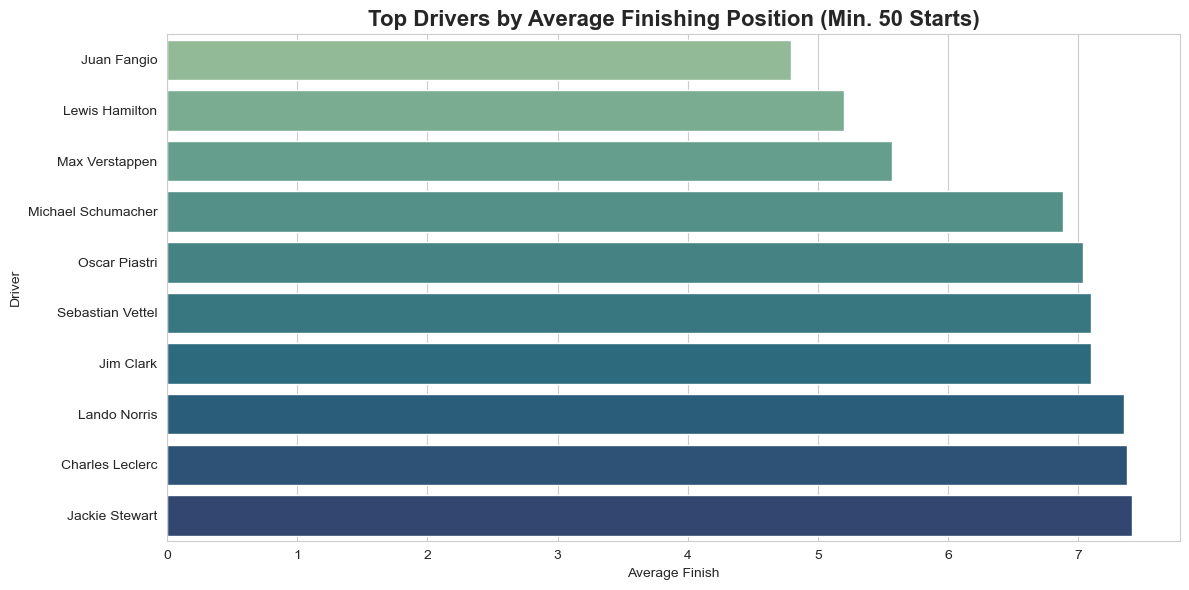

In [76]:
driver_races = (
    results.groupby("driverId")
    .size()
    .reset_index(name="Race Starts")
)

avg_finish_filtered = (
    avg_finish.merge(driver_races, on="driverId")
)

avg_finish_filtered = avg_finish_filtered[
    avg_finish_filtered["Race Starts"] >= 50
]

top10_avg = avg_finish_filtered.sort_values(
    "Average Finish"
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_avg,
    x="Average Finish",
    y="Driver",
    hue="Driver",
    palette="crest",
    legend=False
)

plt.title("Top Drivers by Average Finishing Position (Min. 50 Starts)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Average Finish")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()


# Constructor Analysis

This section analyzes the performance of Formula 1 constructors by examining race entries, wins, podium finishes, and points scored. It helps identify the most successful teams in Formula 1 history.

In [77]:
constructor_entries = (
    results.groupby("constructorId")
    .size()
    .reset_index(name="Race Entries")
    .merge(constructors[["constructorId", "name"]], on="constructorId")
    .sort_values("Race Entries", ascending=False)
)

constructor_entries.head(10)

,constructorId,Race Entries,name
5,6,2509,Ferrari
0,1,1993,McLaren
2,3,1746,Williams
14,15,885,Sauber
24,25,881,Tyrrell
31,32,871,Team Lotus
8,9,858,Red Bull
3,4,787,Renault
128,131,722,Mercedes
17,18,672,Minardi


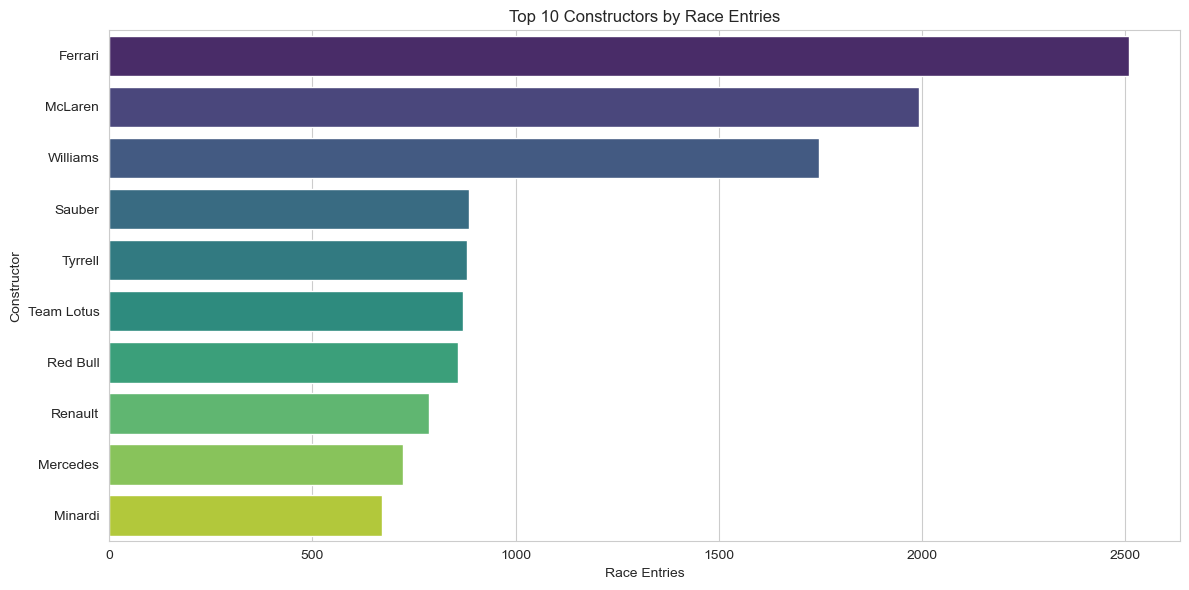

In [78]:
top10_entries = constructor_entries.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_entries,
    x="Race Entries",
    y="name",
    hue="name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Constructors by Race Entries")
plt.xlabel("Race Entries")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

## Constructors with Most Race Wins

This analysis identifies the constructors with the highest number of Formula 1 race victories, highlighting the most successful teams in the sport's history.

In [79]:
constructor_wins = (
    results[results["positionOrder"] == 1]
    .groupby("constructorId")
    .size()
    .reset_index(name="Wins")
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId"
    )
    .sort_values("Wins", ascending=False)
)

constructor_wins.head(10)

,constructorId,Wins,name
5,6,251,Ferrari
0,1,200,McLaren
31,131,139,Mercedes
6,9,130,Red Bull
2,3,114,Williams
14,32,45,Team Lotus
3,4,35,Renault
9,22,27,Benetton
12,25,23,Tyrrell
15,34,23,Brabham


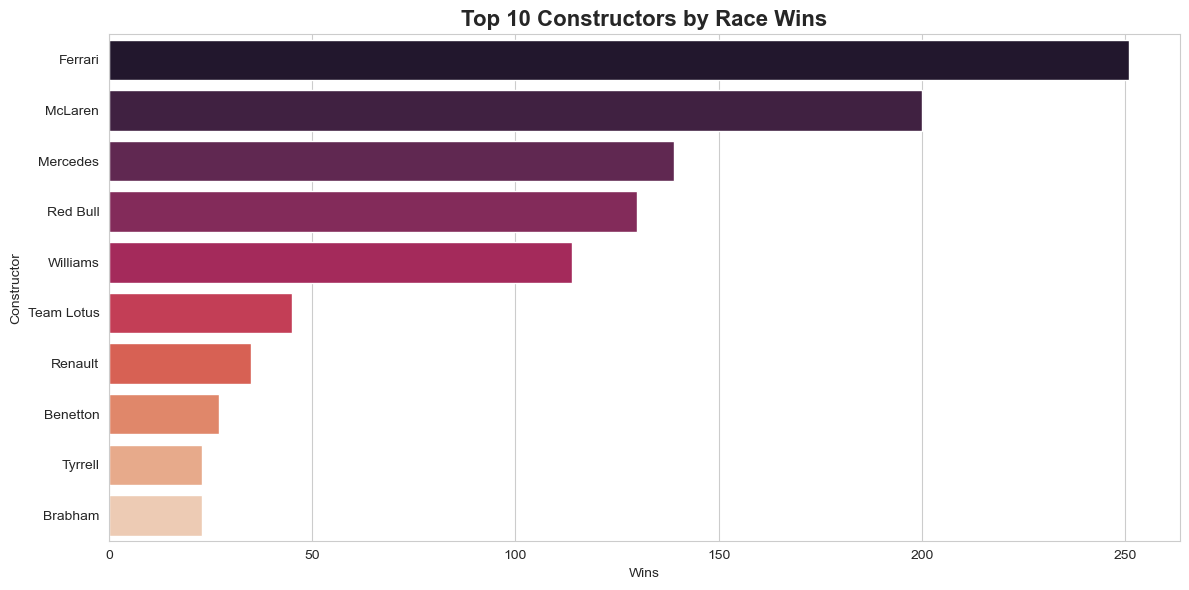

In [80]:
top10_wins = constructor_wins.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_wins,
    x="Wins",
    y="name",
    hue="name",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Constructors by Race Wins", fontsize=16, fontweight="bold")
plt.xlabel("Wins")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

## Constructors with Most Podium Finishes

This analysis identifies the constructors that have achieved the highest number of podium finishes (top three positions), reflecting their consistency and competitiveness over the years.

In [81]:
constructor_podiums = (
    results[results["positionOrder"] <= 3]
    .groupby("constructorId")
    .size()
    .reset_index(name="Podiums")
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId"
    )
    .sort_values("Podiums", ascending=False)
)

constructor_podiums.head(10)

,constructorId,Podiums,name
5,6,857,Ferrari
0,1,547,McLaren
53,131,324,Mercedes
2,3,316,Williams
7,9,301,Red Bull
23,32,114,Team Lotus
3,4,103,Renault
16,22,102,Benetton
25,34,78,Brabham
19,25,77,Tyrrell


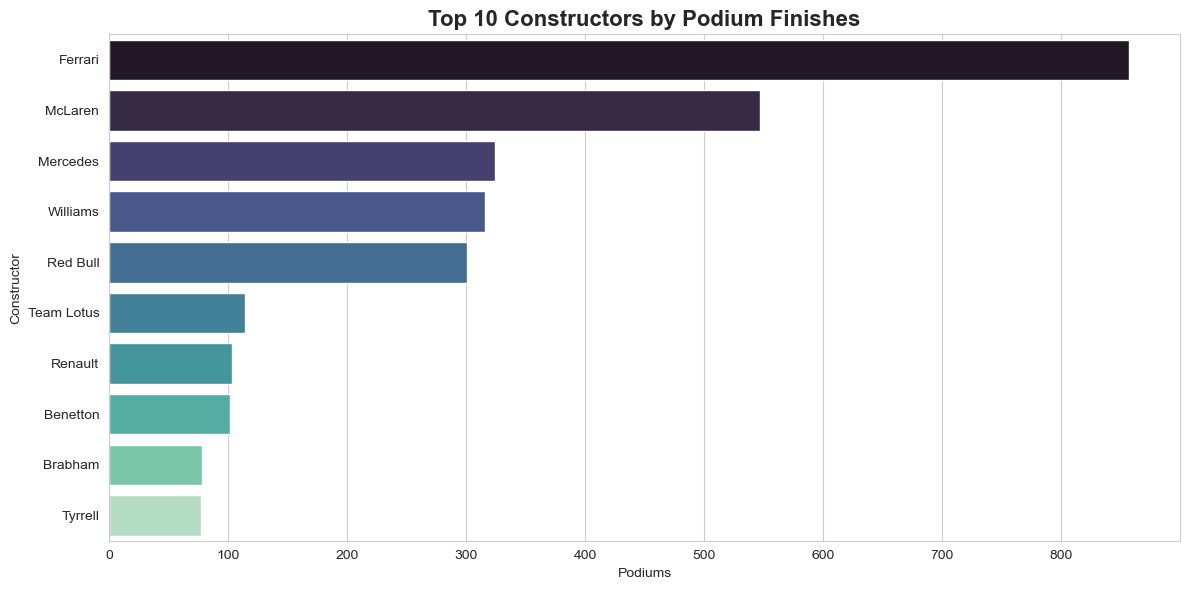

In [82]:
top10_podiums = constructor_podiums.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_podiums,
    x="Podiums",
    y="name",
    hue="name",
    palette="mako",
    legend=False
)

plt.title("Top 10 Constructors by Podium Finishes", fontsize=16, fontweight="bold")
plt.xlabel("Podiums")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

## Constructors with Most Championship Points

This analysis ranks constructors based on the total championship points they have accumulated across all Formula 1 races, providing an overall measure of team performance.

In [83]:
constructor_points = (
    results.groupby("constructorId")["points"]
    .sum()
    .reset_index(name="Total Points")
    .merge(
        constructors[["constructorId", "name"]],
        on="constructorId"
    )
    .sort_values("Total Points", ascending=False)
)

constructor_points.head(10)

,constructorId,Total Points,name
5,6,11719.27,Ferrari
128,131,8486.64,Mercedes
8,9,8251.00,Red Bull
0,1,7974.50,McLaren
2,3,3776.00,Williams
3,4,1777.00,Renault
9,10,1098.00,Force India
31,32,995.00,Team Lotus
21,22,861.50,Benetton
24,25,711.00,Tyrrell


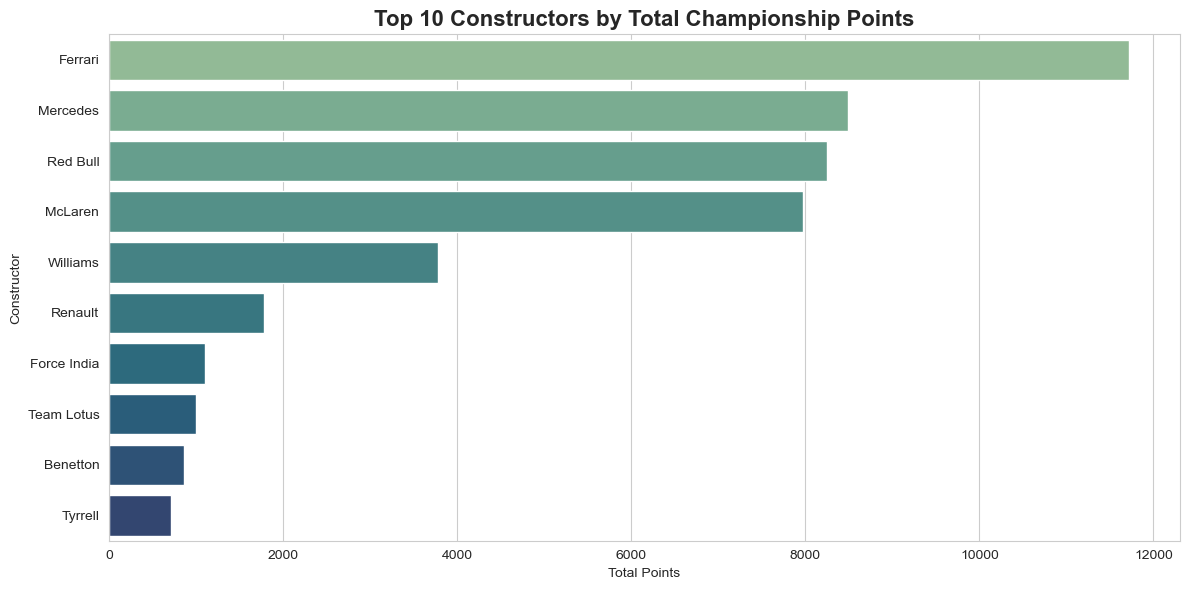

In [84]:
top10_points = constructor_points.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top10_points,
    x="Total Points",
    y="name",
    hue="name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Constructors by Total Championship Points",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Total Points")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

### Summary

The constructor analysis highlights the dominance of Formula 1 teams through race participation, victories, podium finishes, and championship points. These metrics provide a comprehensive view of the most successful and consistent constructors in Formula 1 history.

# Race Analysis

This section explores Formula 1 races from different perspectives, including race participation, race distance, championship points distribution, and historical trends. The objective is to understand how races have evolved across seasons.

## Number of Races per Season

This analysis examines how the Formula 1 calendar has evolved by counting the number of races held in each season.

In [85]:
races_per_season = (
    races.groupby("year")
    .size()
    .reset_index(name="Number of Races")
)

races_per_season.head()

,year,Number of Races
0,1950,7
1,1951,8
2,1952,8
3,1953,9
4,1954,9


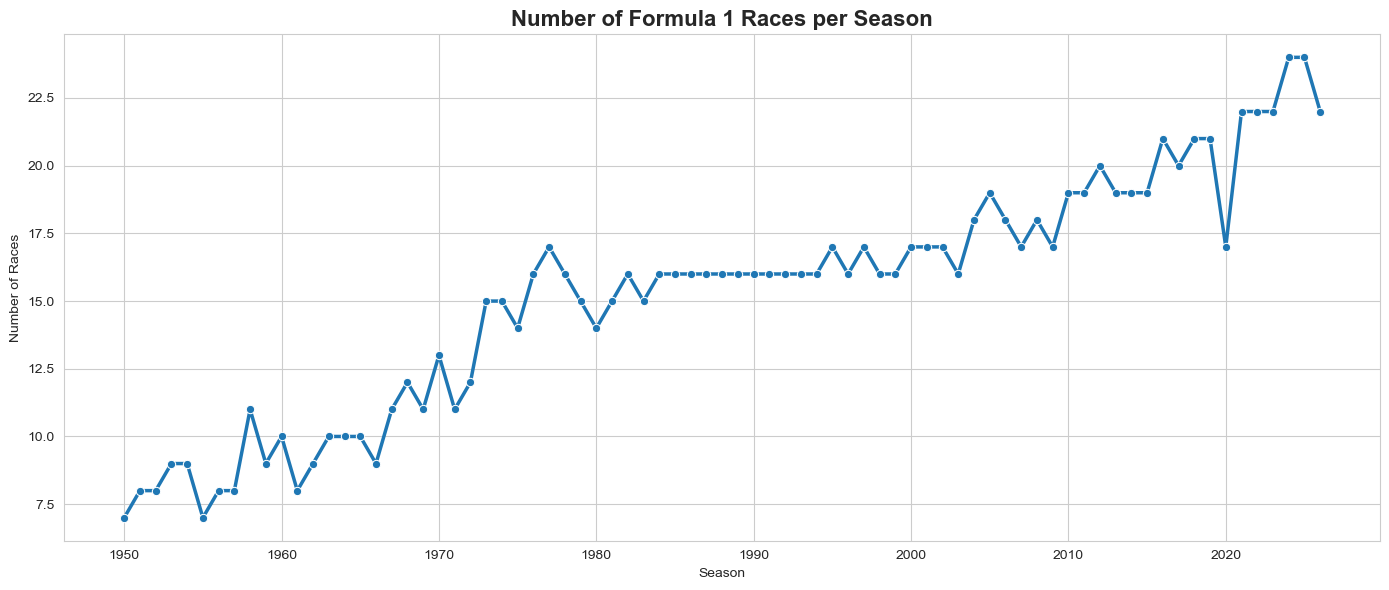

In [86]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=races_per_season,
    x="year",
    y="Number of Races",
    marker="o",
    linewidth=2.5
)

plt.title("Number of Formula 1 Races per Season",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Number of Races")

plt.tight_layout()
plt.show()

## Average Championship Points per Season

This analysis calculates the average championship points awarded per race in each Formula 1 season, helping us understand how the scoring system has evolved over time.

In [87]:
race_points = (
    results.merge(
        races[["raceId", "year"]],
        on="raceId"
    )
)

avg_points = (
    race_points.groupby("year")["points"]
    .mean()
    .reset_index(name="Average Points")
)

avg_points.head()

,year,Average Points
0,1950,1.050000
1,1951,1.072626
2,1952,0.893023
3,1953,0.878049
4,1954,0.937217


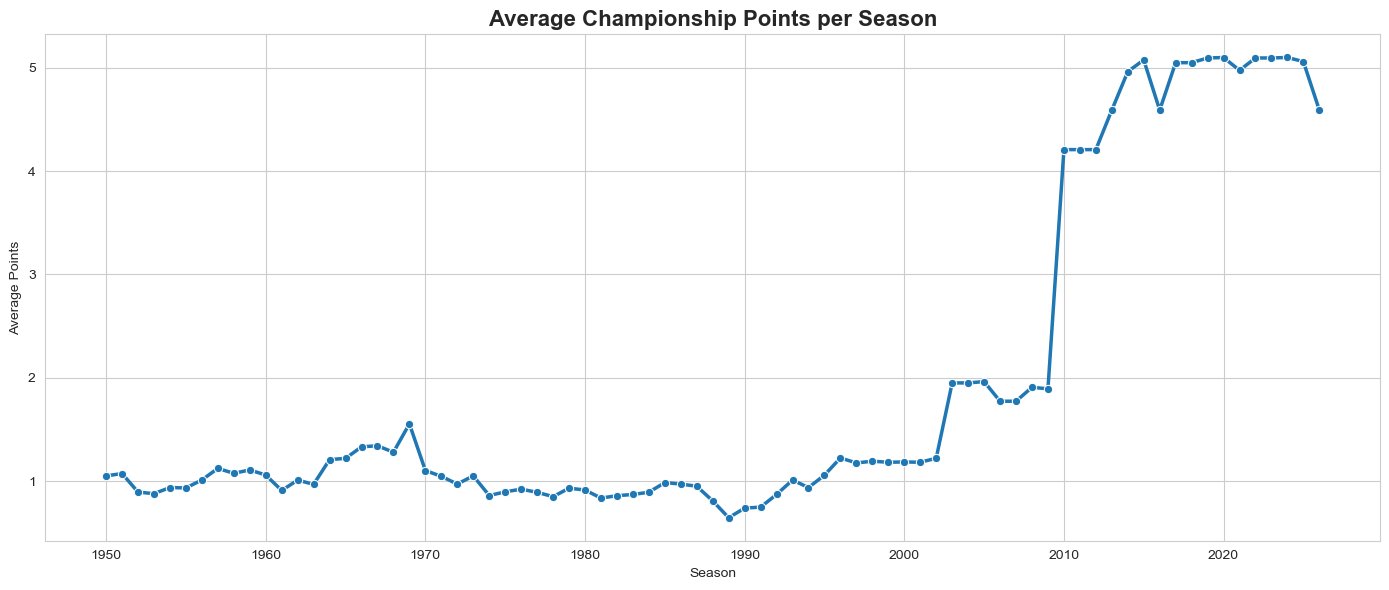

In [88]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=avg_points,
    x="year",
    y="Average Points",
    marker="o",
    linewidth=2.5
)

plt.title("Average Championship Points per Season",
          fontsize=16,
          fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Points")

plt.tight_layout()
plt.show()

## Most Frequently Hosted Circuits

This analysis identifies the circuits that have hosted the highest number of Formula 1 races, highlighting the most iconic and regularly used venues in the championship.

In [89]:
circuit_races = (
    races.merge(
        circuits[["circuitId", "name"]].rename(columns={"name": "Circuit"}),
        on="circuitId"
    )
    .groupby("Circuit")
    .size()
    .reset_index(name="Race Count")
    .sort_values("Race Count", ascending=False)
)

circuit_races.head(10)

,Circuit,Race Count
7,Autodromo Nazionale di Monza,76
25,Circuit de Monaco,72
70,Silverstone Circuit,61
28,Circuit de Spa-Francorchamps,59
20,Circuit Gilles Villeneuve,45
11,Autódromo José Carlos Pace,43
38,Hungaroring,41
57,Nürburgring,41
62,Red Bull Ring,40
37,Hockenheimring,37


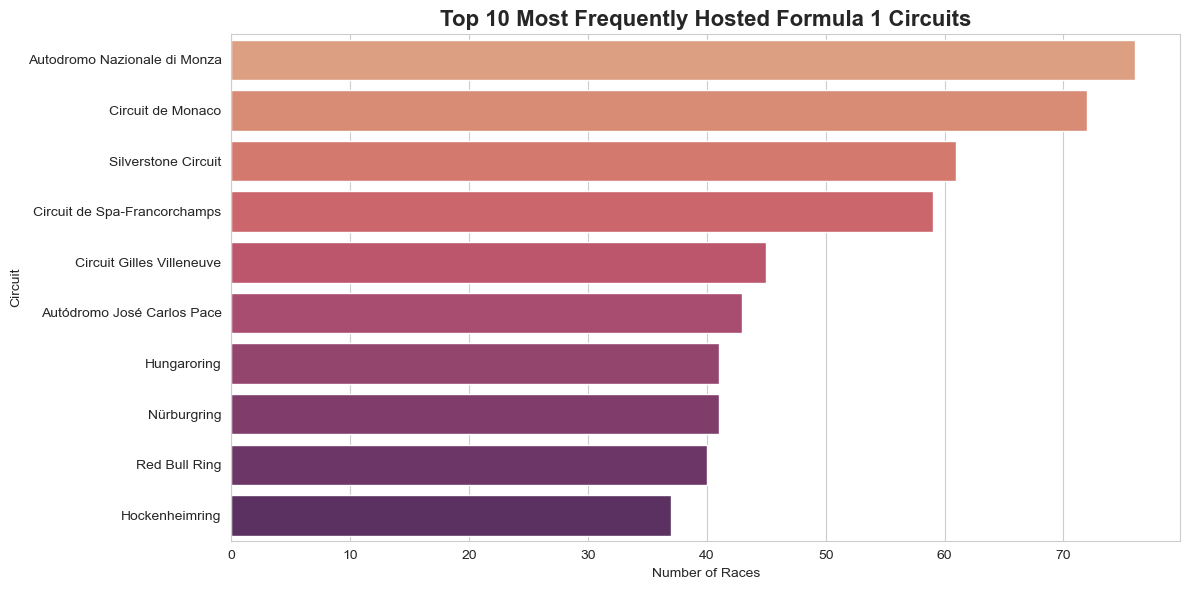

In [90]:
top10_circuits = circuit_races.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_circuits,
    x="Race Count",
    y="Circuit",
    hue="Circuit",
    palette="flare",
    legend=False
)

plt.title("Top 10 Most Frequently Hosted Formula 1 Circuits",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Races")
plt.ylabel("Circuit")

plt.tight_layout()
plt.show()

## Race Winners Distribution

This analysis identifies the drivers with the highest number of Formula 1 race victories across all seasons. It highlights the most successful drivers in the history of the championship.

In [91]:
race_winners = (
    results[results["positionOrder"] == 1]
    .merge(
        drivers[["driverId", "forename", "surname"]],
        on="driverId"
    )
)

race_winners["Driver"] = (
    race_winners["forename"] + " " + race_winners["surname"]
)

winner_distribution = (
    race_winners.groupby("Driver")
    .size()
    .reset_index(name="Wins")
    .sort_values("Wins", ascending=False)
)

winner_distribution.head(10)

,Driver,Wins
67,Lewis Hamilton,106
76,Michael Schumacher,91
75,Max Verstappen,71
107,Sebastian Vettel,53
0,Alain Prost,51
5,Ayrton Senna,41
25,Fernando Alonso,32
82,Nigel Mansell,31
38,Jackie Stewart,27
83,Niki Lauda,25


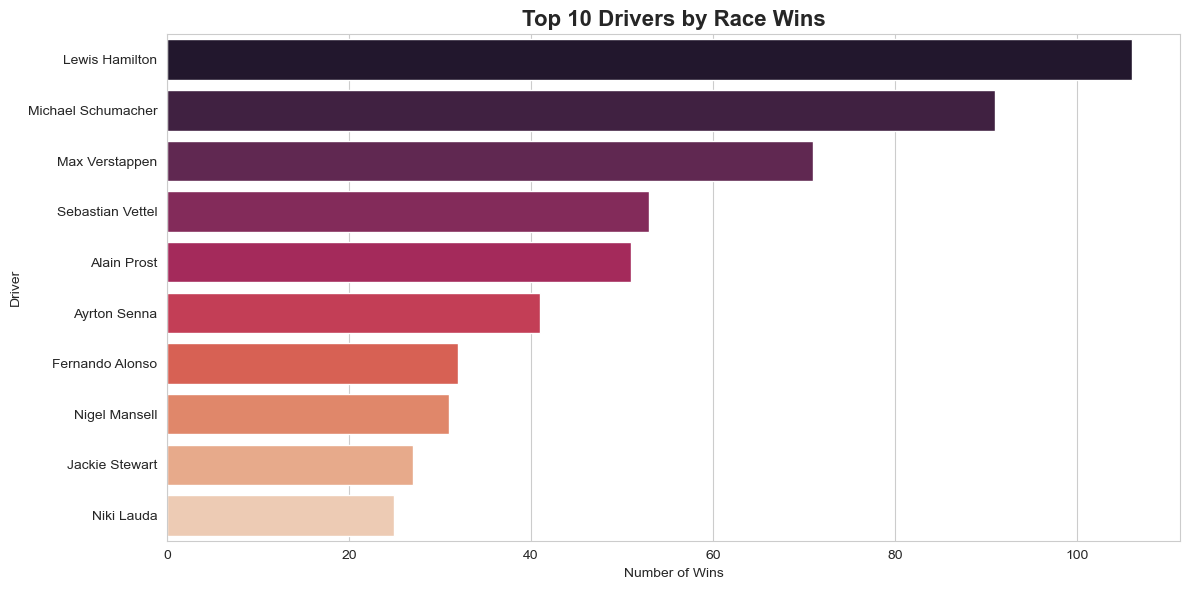

In [92]:
top10_winners = winner_distribution.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_winners,
    x="Wins",
    y="Driver",
    hue="Driver",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Drivers by Race Wins",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Wins")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

# Qualifying Analysis

This section analyzes Formula 1 qualifying performance to understand grid position trends and identify the drivers who have secured the most pole positions throughout the history of the championship.

## Drivers with Most Pole Positions

Pole position is awarded to the driver who qualifies in first place. This analysis identifies the drivers with the highest number of pole positions in Formula 1 history.

In [93]:
pole_positions = (
    qualifying[qualifying["position"] == 1]
    .merge(
        drivers[["driverId", "forename", "surname"]],
        on="driverId"
    )
)

pole_positions["Driver"] = (
    pole_positions["forename"] + " " + pole_positions["surname"]
)

pole_distribution = (
    pole_positions.groupby("Driver")
    .size()
    .reset_index(name="Pole Positions")
    .sort_values("Pole Positions", ascending=False)
)

pole_distribution.head(10)

,Driver,Pole Positions
23,Lewis Hamilton,107
36,Sebastian Vettel,57
25,Max Verstappen,51
26,Michael Schumacher,36
30,Nico Rosberg,30
3,Charles Leclerc,24
8,Fernando Alonso,23
38,Valtteri Bottas,19
20,Kimi Räikkönen,19
22,Lando Norris,17


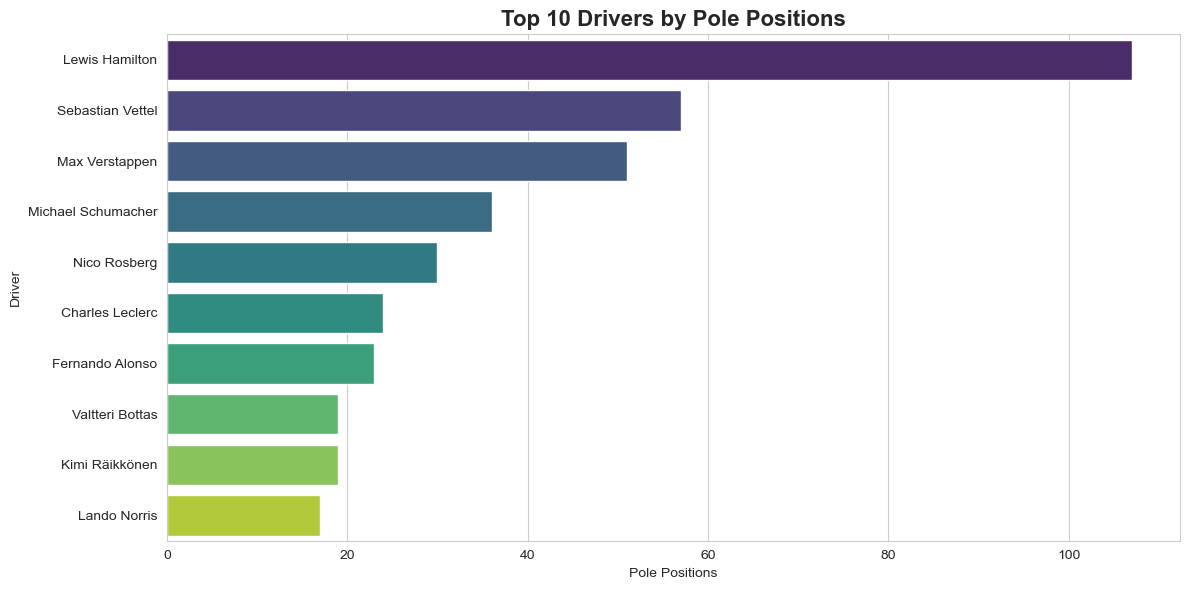

In [94]:
top10_poles = pole_distribution.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_poles,
    x="Pole Positions",
    y="Driver",
    hue="Driver",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Drivers by Pole Positions",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Pole Positions")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

# Correlation Analysis

Correlation analysis measures the relationship between numerical variables in the Formula 1 dataset. It helps identify whether two variables move together positively, negatively, or have little to no relationship.

## Correlation Heatmap

This heatmap visualizes the correlation between important numerical variables such as grid position, finishing position, laps completed, fastest lap speed, and championship points.

In [95]:
results["grid"] = pd.to_numeric(results["grid"], errors="coerce")
results["fastestLapSpeed"] = pd.to_numeric(results["fastestLapSpeed"], errors="coerce")

In [96]:
correlation_data = results[
    ["grid", "positionOrder", "laps", "points", "fastestLapSpeed"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,grid,positionOrder,laps,points,fastestLapSpeed
grid,1.000000,0.173336,0.068290,-0.382046,-0.122251
positionOrder,0.173336,1.000000,-0.648323,-0.580665,-0.164826
laps,0.068290,-0.648323,1.000000,0.248471,-0.074455
points,-0.382046,-0.580665,0.248471,1.000000,0.095725
fastestLapSpeed,-0.122251,-0.164826,-0.074455,0.095725,1.000000


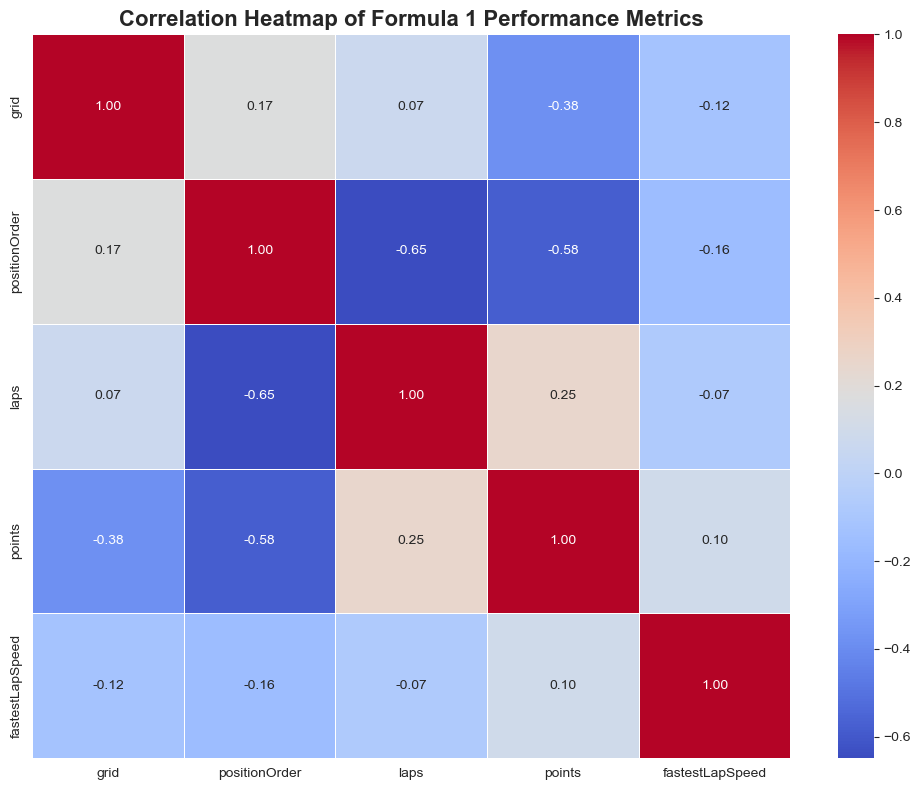

In [97]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap of Formula 1 Performance Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA) Summary

The exploratory data analysis provided valuable insights into Formula 1 historical data by examining seasons, circuits, drivers, constructors, races, qualifying sessions, and the relationships between key performance metrics.

### Key Insights

- Formula 1 has experienced a steady increase in the number of races conducted each season.
- Historic circuits such as Monza, Monaco, and Silverstone have hosted the highest number of Formula 1 races.
- Legendary drivers consistently dominate in race wins, podium finishes, and pole positions.
- Constructors like Ferrari, McLaren, Mercedes, and Red Bull have demonstrated long-term success through victories, podiums, and championship points.
- Correlation analysis indicates that better qualifying positions are generally associated with stronger race finishes and higher championship points.

Overall, the EDA phase helped uncover trends, identify dominant teams and drivers, and better understand the relationships among important racing variables. These insights will guide the next phase of the project, Feature Engineering.

# Feature Engineering

Feature Engineering is the process of creating new variables (features) from existing data to extract more meaningful insights. These engineered features improve data analysis, SQL querying, dashboard development, and machine learning performance by representing complex patterns in a simpler and more informative way.

## Driver Race Count

This feature calculates the total number of Formula 1 races participated in by each driver. It serves as a measure of driver experience and will be used in later analyses and performance metrics.

In [98]:
driver_race_count = (
    results.groupby("driverId")
    .size()
    .reset_index(name="Race Count")
)

driver_race_count = driver_race_count.merge(
    drivers[["driverId", "forename", "surname"]],
    on="driverId"
)

driver_race_count["Driver"] = (
    driver_race_count["forename"] + " " + driver_race_count["surname"]
)

driver_race_count = driver_race_count[
    ["driverId", "Driver", "Race Count"]
].sort_values("Race Count", ascending=False)

driver_race_count.head(10)

,driverId,Driver,Race Count
3,4,Fernando Alonso,439
0,1,Lewis Hamilton,391
7,8,Kimi Räikkönen,352
21,22,Rubens Barrichello,326
17,18,Jenson Button,309
29,30,Michael Schumacher,308
19,20,Sebastian Vettel,300
813,815,Sergio Pérez,294
12,13,Felipe Massa,271
806,807,Nico Hülkenberg,265


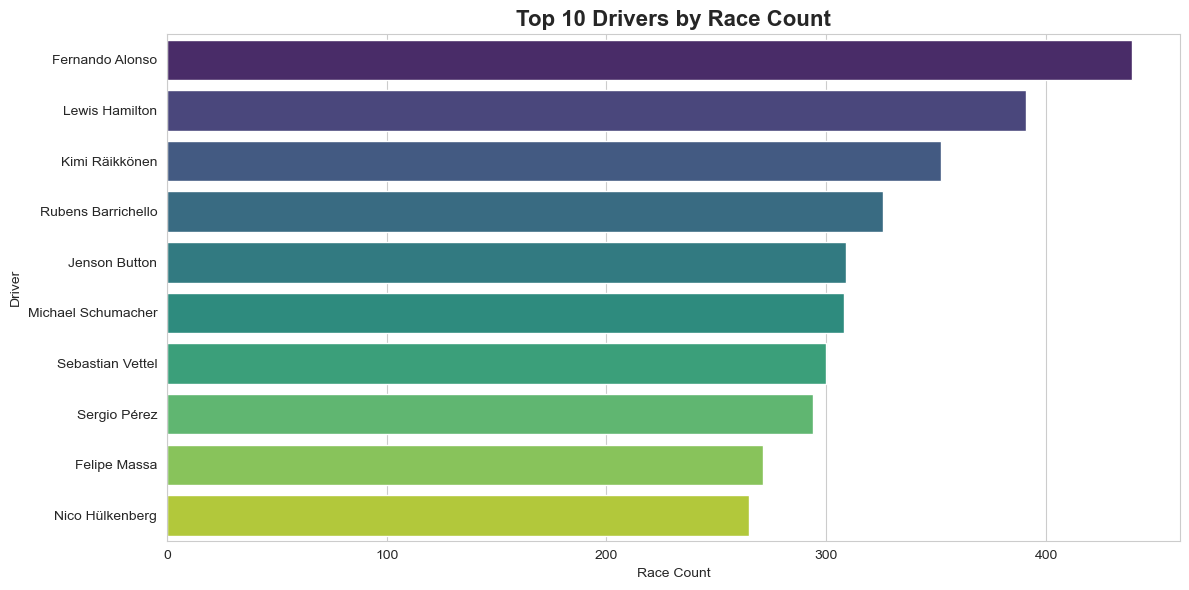

In [99]:
top10_races = driver_race_count.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_races,
    x="Race Count",
    y="Driver",
    hue="Driver",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Drivers by Race Count",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Race Count")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

## Feature 2: Driver Win Rate

Driver Win Rate measures the percentage of races won by each driver relative to the total number of races they have participated in. This feature provides a fair comparison of driver performance by considering both success and experience.

In [100]:
# Calculate total wins for each driver
driver_wins = (
    results[results["positionOrder"] == 1]
    .groupby("driverId")
    .size()
    .reset_index(name="Wins")
)

# Merge with race count
driver_win_rate = driver_race_count.merge(
    driver_wins,
    on="driverId",
    how="left"
)

# Replace missing wins with 0
driver_win_rate["Wins"] = driver_win_rate["Wins"].fillna(0)

# Calculate Win Rate
driver_win_rate["Win Rate (%)"] = (
    driver_win_rate["Wins"] /
    driver_win_rate["Race Count"]
) * 100

# Sort by Win Rate
driver_win_rate = driver_win_rate.sort_values(
    "Win Rate (%)",
    ascending=False
)

driver_win_rate.head(10)

,driverId,Driver,Race Count,Wins,Win Rate (%)
601,766,Lee Wallard,2,1.0,50.000000
143,579,Juan Fangio,58,24.0,41.379310
491,657,Bill Vukovich,5,2.0,40.000000
200,647,Alberto Ascari,36,13.0,36.111111
122,373,Jim Clark,73,25.0,34.246575
5,30,Michael Schumacher,308,91.0,29.545455
15,830,Max Verstappen,244,71.0,29.098361
1,1,Lewis Hamilton,391,106.0,27.109974
85,328,Jackie Stewart,100,27.0,27.000000
46,102,Ayrton Senna,162,41.0,25.308642


## Feature 3: Driver Podium Rate

Driver Podium Rate measures the percentage of races in which a driver finished in the top three positions. It provides a better measure of consistency than simply counting total podium finishes.

In [101]:
# Calculate total podiums for each driver
driver_podiums = (
    results[results["positionOrder"] <= 3]
    .groupby("driverId")
    .size()
    .reset_index(name="Podiums")
)

# Merge with race count
driver_podium_rate = driver_race_count.merge(
    driver_podiums,
    on="driverId",
    how="left"
)

# Replace missing podiums with 0
driver_podium_rate["Podiums"] = (
    driver_podium_rate["Podiums"].fillna(0)
)

# Calculate Podium Rate
driver_podium_rate["Podium Rate (%)"] = (
    driver_podium_rate["Podiums"]
    / driver_podium_rate["Race Count"]
) * 100

# Sort by Podium Rate
driver_podium_rate = driver_podium_rate.sort_values(
    "Podium Rate (%)",
    ascending=False
)

driver_podium_rate.head(10)

,driverId,Driver,Race Count,Podiums,Podium Rate (%)
772,591,George Amick,1,1.0,100.000000
694,802,Dorino Serafini,1,1.0,100.000000
407,786,Luigi Fagioli,8,6.0,75.000000
143,579,Juan Fangio,58,35.0,60.344828
193,642,Nino Farina,37,20.0,54.054054
15,830,Max Verstappen,244,131.0,53.688525
1,1,Lewis Hamilton,391,207.0,52.941176
25,117,Alain Prost,202,106.0,52.475248
229,498,José Froilán González,29,15.0,51.724138
5,30,Michael Schumacher,308,155.0,50.324675


## Feature 4: Average Points per Race

Average Points per Race measures the average number of championship points scored by a driver in each race. It provides a balanced measure of performance by considering both consistency and scoring ability throughout a driver's career.

In [102]:
# Calculate total points for each driver
driver_points = (
    results.groupby("driverId")["points"]
    .sum()
    .reset_index(name="Total Points")
)

# Merge with race count
driver_avg_points = driver_race_count.merge(
    driver_points,
    on="driverId",
    how="left"
)

# Calculate average points per race
driver_avg_points["Average Points per Race"] = (
    driver_avg_points["Total Points"]
    / driver_avg_points["Race Count"]
)

# Sort by average points
driver_avg_points = driver_avg_points.sort_values(
    "Average Points per Race",
    ascending=False
)

driver_avg_points.head(10)

,driverId,Driver,Race Count,Total Points,Average Points per Race
15,830,Max Verstappen,244,3401.5,13.940574
1,1,Lewis Hamilton,391,5106.5,13.060102
6,20,Sebastian Vettel,300,3098.0,10.326667
108,857,Oscar Piastri,81,803.0,9.913580
209,863,Andrea Kimi Antonelli,35,333.0,9.514286
32,844,Charles Leclerc,184,1705.0,9.266304
45,846,Lando Norris,163,1446.0,8.871166
23,3,Nico Rosberg,206,1594.5,7.740291
10,822,Valtteri Bottas,258,1788.0,6.930233
44,847,George Russell,163,1087.0,6.668712


## Feature 4: Average Points per Race

Average Points per Race measures the average number of championship points scored by a driver in each race. It provides a balanced measure of performance by considering both consistency and scoring ability throughout a driver's career.

In [103]:
# Calculate total points for each driver
driver_points = (
    results.groupby("driverId")["points"]
    .sum()
    .reset_index(name="Total Points")
)

# Merge with race count
driver_avg_points = driver_race_count.merge(
    driver_points,
    on="driverId",
    how="left"
)

# Calculate average points per race
driver_avg_points["Average Points per Race"] = (
    driver_avg_points["Total Points"]
    / driver_avg_points["Race Count"]
)

# Sort by average points
driver_avg_points = driver_avg_points.sort_values(
    "Average Points per Race",
    ascending=False
)

driver_avg_points.head(10)

,driverId,Driver,Race Count,Total Points,Average Points per Race
15,830,Max Verstappen,244,3401.5,13.940574
1,1,Lewis Hamilton,391,5106.5,13.060102
6,20,Sebastian Vettel,300,3098.0,10.326667
108,857,Oscar Piastri,81,803.0,9.913580
209,863,Andrea Kimi Antonelli,35,333.0,9.514286
32,844,Charles Leclerc,184,1705.0,9.266304
45,846,Lando Norris,163,1446.0,8.871166
23,3,Nico Rosberg,206,1594.5,7.740291
10,822,Valtteri Bottas,258,1788.0,6.930233
44,847,George Russell,163,1087.0,6.668712


## Feature 5: Constructor Win Rate

Constructor Win Rate measures the percentage of races won by each Formula 1 constructor relative to the total number of races they have participated in. This feature helps evaluate the overall efficiency and competitiveness of teams across different seasons.

In [104]:
# Calculate total races for each constructor
constructor_race_count = (
    results.groupby("constructorId")
    .size()
    .reset_index(name="Race Count")
)

# Calculate total wins for each constructor
constructor_wins = (
    results[results["positionOrder"] == 1]
    .groupby("constructorId")
    .size()
    .reset_index(name="Wins")
)

# Merge race count and wins
constructor_win_rate = constructor_race_count.merge(
    constructor_wins,
    on="constructorId",
    how="left"
)

# Replace missing values
constructor_win_rate["Wins"] = (
    constructor_win_rate["Wins"].fillna(0)
)

# Calculate Win Rate
constructor_win_rate["Win Rate (%)"] = (
    constructor_win_rate["Wins"]
    / constructor_win_rate["Race Count"]
) * 100

# Add constructor names
constructor_win_rate = constructor_win_rate.merge(
    constructors[["constructorId", "name"]],
    on="constructorId"
)

# Rearrange columns
constructor_win_rate = constructor_win_rate[
    ["constructorId", "name", "Race Count", "Wins", "Win Rate (%)"]
]

# Sort by Win Rate
constructor_win_rate = constructor_win_rate.sort_values(
    "Win Rate (%)",
    ascending=False
)

constructor_win_rate.head(10)

,constructorId,name,Race Count,Wins,Win Rate (%)
22,23,Brawn,34,8.0,23.529412
192,196,Matra-Ford,40,9.0,22.500000
128,131,Mercedes,722,139.0,19.252078
8,9,Red Bull,858,130.0,15.151515
115,118,Vanwall,71,10.0,14.084507
104,107,Watson,22,3.0,13.636364
105,108,Epperly,17,2.0,11.764706
187,191,Brabham-Repco,77,8.0,10.389610
0,1,McLaren,1993,200.0,10.035123
5,6,Ferrari,2509,251.0,10.003986


## Feature 7: Driver Experience Level

Driver Experience Level categorizes drivers based on the total number of Formula 1 races they have participated in. This feature helps distinguish between rookie, intermediate, experienced, and veteran drivers, making it easier to compare performance across different experience levels.

In [105]:
# Create Experience Level based on Race Count
driver_race_count["Experience Level"] = pd.cut(
    driver_race_count["Race Count"],
    bins=[0, 50, 150, 300, float("inf")],
    labels=["Rookie", "Intermediate", "Experienced", "Veteran"]
)

driver_race_count.head(10)

,driverId,Driver,Race Count,Experience Level
3,4,Fernando Alonso,439,Veteran
0,1,Lewis Hamilton,391,Veteran
7,8,Kimi Räikkönen,352,Veteran
21,22,Rubens Barrichello,326,Veteran
17,18,Jenson Button,309,Veteran
29,30,Michael Schumacher,308,Veteran
19,20,Sebastian Vettel,300,Experienced
813,815,Sergio Pérez,294,Experienced
12,13,Felipe Massa,271,Experienced
806,807,Nico Hülkenberg,265,Experienced


## Feature 8: Grid Position Gain/Loss

Grid Position Gain/Loss measures the difference between a driver's starting position on the grid and their final finishing position in a race. A positive value indicates that the driver gained positions during the race, while a negative value indicates positions lost.

In [106]:
# Create Grid Position Gain/Loss feature
results["Position Gain/Loss"] = (
    results["grid"] - results["positionOrder"]
)

results[
    ["driverId", "grid", "positionOrder", "Position Gain/Loss"]
].head(10)

,driverId,grid,positionOrder,Position Gain/Loss
0,1,1.0,1,0.0
1,2,5.0,2,3.0
2,3,7.0,3,4.0
3,4,11.0,4,7.0
4,5,3.0,5,-2.0
5,6,13.0,6,7.0
6,7,17.0,7,10.0
7,8,15.0,8,7.0
8,9,2.0,9,-7.0
9,10,18.0,10,8.0


## Feature 9: Season Performance Metrics

Season Performance Metrics summarize a driver's performance for each Formula 1 season by calculating the total championship points, race wins, and average finishing position. These metrics help compare driver performance across different seasons.

In [107]:
# Merge results with races to get season (year)
season_performance = results.merge(
    races[["raceId", "year"]],
    on="raceId"
)

# Calculate season-wise metrics
season_performance = (
    season_performance
    .groupby(["driverId", "year"])
    .agg(
        Total_Points=("points", "sum"),
        Wins=("positionOrder", lambda x: (x == 1).sum()),
        Average_Finish=("positionOrder", "mean"),
        Total_Races=("raceId", "count")
    )
    .reset_index()
)

season_performance.head(10)

,driverId,year,Total_Points,Wins,Average_Finish,Total_Races
0,1,2007,109.0,4,3.941176,17
1,1,2008,98.0,5,5.222222,18
2,1,2009,49.0,2,9.705882,17
3,1,2010,240.0,3,6.421053,19
4,1,2011,227.0,3,6.736842,19
5,1,2012,190.0,4,9.600000,20
6,1,2013,189.0,1,5.947368,19
7,1,2014,384.0,11,4.105263,19
8,1,2015,381.0,10,2.578947,19
9,1,2016,380.0,10,3.761905,21


## Feature 10: Final Feature Dataset

The Final Feature Dataset combines all engineered features into a single dataset. This dataset provides a comprehensive view of each driver's performance and experience, making it suitable for SQL analysis, Power BI dashboards, and predictive modeling.

In [108]:
# Calculate total podiums for each driver
driver_podiums = (
    results[results["positionOrder"] <= 3]
    .groupby("driverId")
    .size()
    .reset_index(name="Podiums")
)

driver_podium_rate = driver_race_count.merge(
    driver_podiums,
    on="driverId",
    how="left"
)

driver_podium_rate["Podiums"] = (
    driver_podium_rate["Podiums"].fillna(0)
)

driver_podium_rate["Podium Rate (%)"] = (
    driver_podium_rate["Podiums"]
    / driver_podium_rate["Race Count"]
) * 100

driver_podium_rate.head()

,driverId,Driver,Race Count,Experience Level,Podiums,Podium Rate (%)
0,4,Fernando Alonso,439,Veteran,106.0,24.145786
1,1,Lewis Hamilton,391,Veteran,207.0,52.941176
2,8,Kimi Räikkönen,352,Veteran,103.0,29.261364
3,22,Rubens Barrichello,326,Veteran,68.0,20.858896
4,18,Jenson Button,309,Veteran,50.0,16.181230
